In [32]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [33]:
image_dir = "/content/drive/MyDrive/Dataset/"   # main folder

img_height = 128
img_width = 128
batch_size = 16
epochs = 20

In [34]:
def load_all_good_images(base_dir, img_size=(128,128)):
    images = []

    # Loop through all type folders
    for folder in os.listdir(base_dir):
        type_path = os.path.join(base_dir, folder)

        if os.path.isdir(type_path):
            good_path = os.path.join(type_path, "train", "good")

            if os.path.exists(good_path):
                print(f"Loading from: {good_path}")

                for img_file in tqdm(os.listdir(good_path), desc=f"{folder}"):
                    img_path = os.path.join(good_path, img_file)

                    img = cv2.imread(img_path)
                    if img is None:
                        continue

                    img = cv2.resize(img, img_size)
                    img = img.astype(np.float32) / 255.0

                    images.append(img)

    return np.array(images)

In [35]:
X = load_all_good_images(image_dir, img_size=(img_height, img_width))

print("Total images loaded:", X.shape)

Loading from: /content/drive/MyDrive/Dataset/type5cam2/train/good


type5cam2: 100%|██████████| 181/181 [00:01<00:00, 97.86it/s] 


Loading from: /content/drive/MyDrive/Dataset/type9cam2/train/good


type9cam2: 100%|██████████| 721/721 [00:08<00:00, 89.77it/s] 


Loading from: /content/drive/MyDrive/Dataset/type3cam1/train/good


...

Loading from: /content/drive/MyDrive/Dataset/type10cam2/train/good


type10cam2: 100%|██████████| 717/717 [00:07<00:00, 93.49it/s] 


Loading from: /content/drive/MyDrive/Dataset/type8cam1/train/good


type8cam1: 100%|██████████| 711/711 [00:08<00:00, 80.67it/s] 


Total images loaded: (4391, 128, 128, 3)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

np.random.shuffle(X_train)

In [54]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Add

# ======================
# Residual Block
# ======================
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = Conv2D(filters, 3, activation='relu', padding='same')(x)

    # Match channels for addition
    shortcut = Conv2D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    return x

# ======================
# ResUNet Model
# ======================
def build_resunet(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    # ========= Encoder =========
    c1 = residual_block(inputs, 32)
    p1 = MaxPooling2D()(c1)

    c2 = residual_block(p1, 64)
    p2 = MaxPooling2D()(c2)

    c3 = residual_block(p2, 128)
    p3 = MaxPooling2D()(c3)

    # ========= Bottleneck =========
    b = residual_block(p3, 256)

    # ========= Decoder =========
    u1 = Conv2DTranspose(128, 2, strides=2, padding='same')(b)
    u1 = Concatenate()([u1, c3])
    c4 = residual_block(u1, 128)

    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    u2 = Concatenate()([u2, c2])
    c5 = residual_block(u2, 64)

    u3 = Conv2DTranspose(32, 2, strides=2, padding='same')(c5)
    u3 = Concatenate()([u3, c1])
    c6 = residual_block(u3, 32)

    # ========= Output =========
    outputs = Conv2D(3, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)

In [56]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return mse + ssim_loss(y_true, y_pred)

model = build_resunet((img_height, img_width, 3))

model.compile(
    optimizer=Adam(1e-4),
    loss=combined_loss
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_51[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 128, 128,  │        128 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ conv2d_52[0][0],  │
│                     │ 32)               │            │ conv2d_53[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_54[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 64, 64,    │      2,112 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ conv2d_55[0][0],  │
│                     │ 64)               │            │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_57[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 32, 32,    │      8,320 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_58[0][0],  │
│                     │ 128)              │            │ conv2d_59[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 16,    │          0 │ add_2[0][0]       │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_11

 Total params: 2,012,483 (7.68 MB)

 Trainable params: 2,012,483 (7.68 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 144ms/step - loss: 0.2437 - val_loss: 0.0477
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0324 - val_loss: 0.0217
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0176 - val_loss: 0.0145
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0129 - val_loss: 0.0117
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0105 - val_loss: 0.0099
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0089 - val_loss: 0.0082
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0080 - val_loss: 0.0073
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0067 - val_loss: 0.0065
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0060 - val_loss: 0.0058
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0054 - val_loss: 0.0051
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0051 - val_loss: 0.0048
Epoch 12/20
220/220 ━━━━━━━━━

In [59]:
model.save("/content/drive/MyDrive/resunet_model.h5")

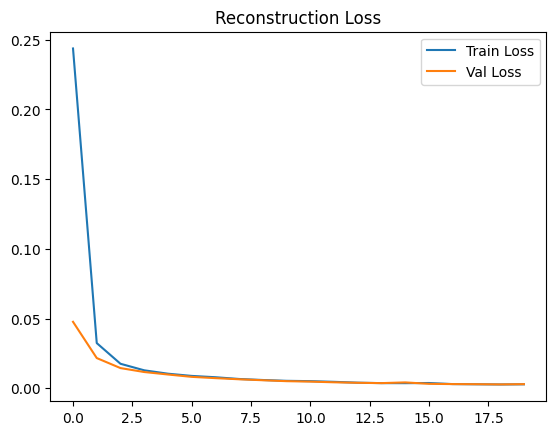

In [60]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.show()

In [61]:
val_errors = []

crop = 10   # ignore border pixels

# Iterate directly over the validation image data from X_val
# X_val already contains normalized images
for img_data_single in X_val[:100]:
    img_input = np.expand_dims(img_data_single, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise error
    error_map = np.mean((img_data_single - recon) ** 2, axis=2) # Compare original image data with reconstruction

    # ✅ Smooth error (reduce noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Top-K scoring (more robust)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-300:])   # top 300 pixels

    val_errors.append(score)

# ✅ Final threshold
threshold = np.mean(val_errors) + 2 * np.std(val_errors)

print("Threshold:", threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━

Saving 58.png to 58.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


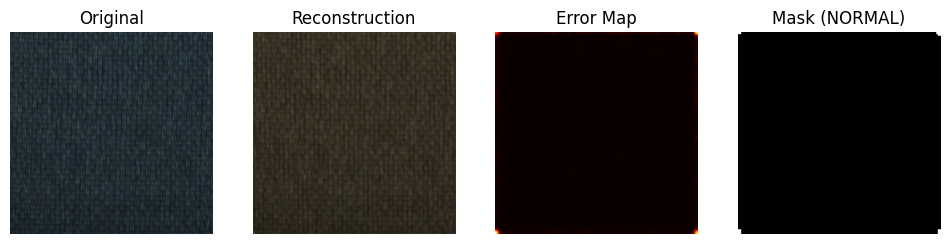

Score: 9.511834109900442e-06
Prediction: NORMAL


In [63]:
from google.colab import files

uploaded = files.upload()

crop = 10   # ignore edges

for filename in uploaded.keys():
    img = cv2.imread(filename)
    original_size = img.shape[:2]

    img_resized = cv2.resize(img, (img_width, img_height))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise MSE error
    error_map = np.mean((img_norm - recon) ** 2, axis=2)

    # ✅ Smooth error (removes texture noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Resize for visualization
    error_map_resized = cv2.resize(error_map, (original_size[1], original_size[0]))

    # ✅ Pixel threshold (ONLY on cropped region)
    #pixel_threshold = np.percentile(cropped_error, 99)

    # ✅ Mask creation

    # ✅ Normalize error map (0 → 1)
    norm_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # ✅ Threshold based on intensity (like red region)
    pixel_threshold = 0.2   # you can tune: 0.3–0.6

    mask = (norm_error > pixel_threshold).astype(np.uint8) * 255
    # mask = np.zeros_like(error_map, dtype=np.uint8)
    # mask[crop:h-crop, crop:w-crop] = (cropped_error > pixel_threshold).astype(np.uint8)

    # ✅ Resize mask
    # mask = cv2.resize(mask, (original_size[1], original_size[0])) * 255

    # 🔥 Morphological cleaning
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # ✅ Better scoring (Top-K on cropped region)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-5:])

    # ✅ Classification
    label = "ANOMALY" if score > threshold else "NORMAL"

    # 🔥 Normalize error map for display
    vis_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(recon.astype(np.float32)) # Cast recon to float32
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(vis_error.astype(np.float32), cmap='hot') # Cast vis_error to float32
    plt.title("Error Map")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask ({label})")
    plt.axis("off")

    plt.show()

    print("Score:", score)
    print("Prediction:", label)
